<a href="https://colab.research.google.com/github/AzadMahmud/dl-lab/blob/main/assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib captum

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from captum.attr import IntegratedGradients

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(64, num_classes)

        self.feature_maps = None

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))

        self.feature_maps = x

        x = self.pool(x)

        x = self.gap(x)

        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x

In [4]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

classes = trainset.classes

100%|██████████| 170M/170M [00:51<00:00, 3.28MB/s]


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(2):
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} done")

Epoch 1 done
Epoch 2 done


In [6]:
def generate_cam(model, image, class_idx):
    output = model(image)

    weights = model.fc.weight[class_idx].detach().cpu()

    feature_maps = model.feature_maps.squeeze(0).detach().cpu()

    cam = torch.zeros(feature_maps.shape[1:])

    for i, w in enumerate(weights):
        cam += w * feature_maps[i]

    cam = torch.relu(cam)

    cam -= cam.min()
    cam /= cam.max() + 1e-8

    return cam.numpy()

In [7]:
def generate_gradcam(model, image, class_idx):
    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    handle_f = model.conv2.register_forward_hook(forward_hook)
    handle_b = model.conv2.register_backward_hook(backward_hook)

    output = model(image)
    model.zero_grad()
    output[0, class_idx].backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=(2,3), keepdim=True)
    cam = (weights * acts).sum(dim=1).squeeze()

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / cam.max()

    handle_f.remove()
    handle_b.remove()

    return cam.detach().cpu().numpy()

In [8]:
def generate_ig(model, image, class_idx):
    ig = IntegratedGradients(model)
    attributions = ig.attribute(image, target=class_idx)
    attr = attributions.squeeze().cpu().detach().numpy()
    attr = np.transpose(attr, (1,2,0))
    attr = (attr - attr.min()) / (attr.max() - attr.min())
    return attr

In [9]:
def show_results(image, cam, gradcam, ig):
    img = image.squeeze().cpu().permute(1,2,0).numpy()

    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)

    plt.subplot(1,4,2)
    plt.title("CAM")
    plt.imshow(cam, cmap='jet')

    plt.subplot(1,4,3)
    plt.title("Grad-CAM")
    plt.imshow(gradcam, cmap='jet')

    plt.subplot(1,4,4)
    plt.title("IG")
    plt.imshow(ig)

    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


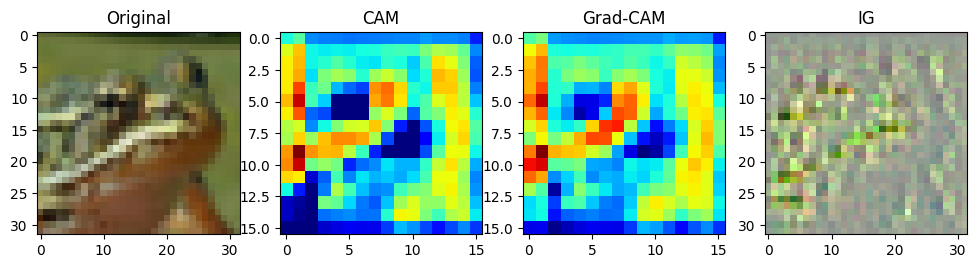

In [10]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

img = images[0].unsqueeze(0).to(device)
label = labels[0].item()

output = model(img)
pred = output.argmax(dim=1).item()

cam = generate_cam(model, img, pred)
gradcam = generate_gradcam(model, img, pred)
ig = generate_ig(model, img, pred)

show_results(img, cam, gradcam, ig)

In [11]:
from google.colab import files
uploaded = files.upload()

Saving second_male_1.jpg to second_male_1.jpg
Saving second_male_2.jpg to second_male_2.jpg
Saving second_male_3.jpg to second_male_3.jpg
Saving second_male_4.jpg to second_male_4.jpg
Saving second_male_5.jpg to second_male_5.jpg


In [12]:
from PIL import Image

face_images = []
labels = []

label_map = {}  # manually assign labels

for i, file in enumerate(uploaded.keys()):
    img = Image.open(file).convert("RGB")
    img = img.resize((32,32))
    img = transforms.ToTensor()(img)

    face_images.append(img)
    labels.append(i)  # simple label

face_images = torch.stack(face_images)
labels = torch.tensor(labels)

In [13]:
face_model = SimpleCNN(num_classes=len(face_images)).to(device)

optimizer = torch.optim.Adam(face_model.parameters(), lr=0.001)

for epoch in range(10):
    outputs = face_model(face_images.to(device))
    loss = criterion(outputs, labels.to(device))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} Loss: {loss.item()}")

Epoch 1 Loss: 1.6145607233047485
Epoch 2 Loss: 1.602193832397461
Epoch 3 Loss: 1.5929992198944092
Epoch 4 Loss: 1.5857797861099243
Epoch 5 Loss: 1.579671859741211
Epoch 6 Loss: 1.5737451314926147
Epoch 7 Loss: 1.5675944089889526
Epoch 8 Loss: 1.5608981847763062
Epoch 9 Loss: 1.5534145832061768
Epoch 10 Loss: 1.5450000762939453


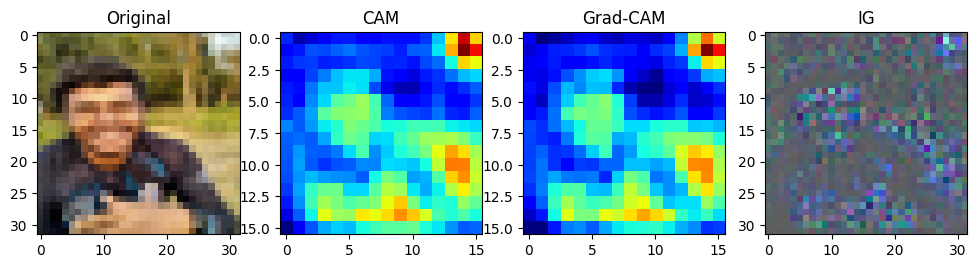

In [14]:
img = face_images[0].unsqueeze(0).to(device)

output = face_model(img)
pred = output.argmax(dim=1).item()

cam = generate_cam(face_model, img, pred)
gradcam = generate_gradcam(face_model, img, pred)
ig = generate_ig(face_model, img, pred)

show_results(img, cam, gradcam, ig)